# Lab: Polynomial Regression

*In this lab, we will build a **Polynomial Regression** model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

## Stages 1-5
This lab notebook builds directly on the findings from the [Multiple Linear Regression Lab](./07_multiple_linear_regression_lab.ipynb), where we aimed to build a predictive model using data on TV, Radio, and Newspaper advertising to better explain sales variance and guide budget allocation. Therefore Stages 1 through 5 (Business Understanding, Analytic Approach, Data Requirements, Data Collection, and Data Understanding) are considered complete. We will proceed directly with preparing the data for our new Polynomial Regression model.

---

> ### 📝 1-5. Previous Stages Report (Summary)
> *   **Strong Initial Performance:** The Multiple Linear Regression model achieved a high R-squared of **~0.90**, explaining about 90% of the variance in sales.
> *   **Key Insight:** The model identified `TV` and `Radio` as strong, statistically significant predictors, while proving that `Newspaper` spend was statistically insignificant.
> *   **Critical Flaw:** The model's **residual plot showed a distinct U-shaped pattern**, indicating that it systematically under-predicted sales for low and high-spending markets and over-predicted for mid-range markets. This violated the linearity assumption.
> *   **Decision and Next Steps:** Due to the systematic errors revealed in the residual analysis, the decision was **"No-Go for Deployment."** The recommended next step was to experiment with a model capable of capturing non-linear relationships.
>


---

## Stage 6: Data Preparation
Again, we won't need a data cleaning step, but we still need to import necessary libraries and load our data.

In [32]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)

In [33]:
sales_df = pd.read_csv("./data/advertising.csv", usecols=['TV', 'Radio', 'Newspaper', 'Sales'])
sales_df.columns = [col.lower() for col in sales_df.columns]
sales_df.head()

,tv,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 6.1. Final Dataset Split
This time we will define two feature matrices: one with all three features (`TV`, `Radio`, and `Newspaper`) and another with only the two significant features (`TV` and `Radio`). We will then split both datasets into training and testing sets.

In [34]:
# Create feature matrices and target vector
X_all = sales_df[['tv', 'radio', 'newspaper']]
X_significant = sales_df[['tv', 'radio']]
y = sales_df['sales']

# Split the data into training and testing sets
X_all_train, X_all_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)
X_sig_train, X_sig_test, _, _ = train_test_split(X_significant, y, test_size=0.2, random_state=42)

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_all_train_poly = poly.fit_transform(X_all_train)
X_all_test_poly = poly.transform(X_all_test)
X_sig_train_poly = poly.fit_transform(X_sig_train)
X_sig_test_poly = poly.transform(X_sig_test)

---

> ### 📝 6. Data Preparation Report (Summary)
> *   **Data Loading:** The advertising dataset was successfully loaded, containing columns for `TV`, `Radio`, `Newspaper`, and `Sales`.
> *   **Feature Selection:** Two feature matrices were created: one with all three advertising channels and another with only `TV` and `Radio`, based on prior significance analysis.
> *   **Data Splitting:** Both datasets were split into training (80%) and testing (20%) sets using a fixed random state for reproducibility.
> *   **Next Steps:** Proceed to Stage 7: Model Building, where we will implement Polynomial Regression on both feature sets and evaluate their performance.

---

## 7. Modeling


### 7.1. Load the Baseline Model
Our base model is the Multiple Linear Regression model from the previous lab. Let's load it first.

In [35]:
multiple_linear_model = joblib.load("./models/multiple_linear_regression_model.pkl")

### 7.2. Train Candidate Models
Now we will create two Polynomial Regression models: one using all three features and another using only the two significant features.

In [36]:
poly_all_model = LinearRegression().fit(X_all_train_poly, y_train)
poly_sig_model = LinearRegression().fit(X_sig_train_poly, y_train)

> ### 📝 7. Modeling Report (Summary)
> *   **Baseline Model:** The Multiple Linear Regression model was loaded as a baseline for comparison.
> *   **Candidate Models:** Two Polynomial Regression models were trained: one with all three features and another with only `TV` and `Radio`.
> *   **Model Training:** Both models were trained on their respective training sets using polynomial features of degree 2.
> *   **Next Steps:** Proceed to *Stage 8: Evaluation*, where we will assess the performance of all three models using appropriate metrics and residual analysis.

---

## Stage 8: Evaluation

### 8.1. Model Performances on the Test Set
Now we will evaluate the performance of all three models on the test set using R-squared and RMSE metrics.

In [45]:
# Multiple Linear Regression Model Predictions and Evaluation Metrics
y_pred_mlr = multiple_linear_model.predict(X_all_test)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

# Polynomial Regression Model (All Features) Predictions and Evaluation Metrics
y_pred_poly_all = poly_all_model.predict(X_all_test_poly)
mse_poly_all = mean_squared_error(y_test, y_pred_poly_all)
r2_poly_all = r2_score(y_test, y_pred_poly_all)

# Polynomial Regression Model (Significant Features) Predictions and Evaluation Metrics
y_pred_poly_sig = poly_sig_model.predict(X_sig_test_poly)
mse_poly_sig = mean_squared_error(y_test, y_pred_poly_sig)
r2_poly_sig = r2_score(y_test, y_pred_poly_sig)

# Print evaluation metrics
print("Multiple Linear Regression Model:")
print(f"  MSE: {mse_mlr:.4f}")
print(f"  R²: {r2_mlr:.4f}\n")
print("Polynomial Regression Model (All Features):")
print(f"  MSE: {mse_poly_all:.4f}")
print(f"  R²: {r2_poly_all:.4f}\n")
print("Polynomial Regression Model (Significant Features):")
print(f"  MSE: {mse_poly_sig:.4f}")
print(f"  R²: {r2_poly_sig:.4f}")

Multiple Linear Regression Model:
  MSE: 3.1741
  R²: 0.8994

Polynomial Regression Model (All Features):
  MSE: 0.4129
  R²: 0.9869

Polynomial Regression Model (Significant Features):
  MSE: 0.3642
  R²: 0.9885


#### 📌 Key Findings From Evaluation Metrics
*  The Polynomial Regression model using only the significant features (`TV` and `Radio`) outperformed both the baseline Multiple Linear Regression model and the Polynomial Regression model using all features.
*  This model achieved the highest R-squared (0.9885) and the lowest RMSE (0.3642), indicating it best captures the underlying relationship in the data without overfitting.

### 8.2. Residual Analysis
We will now visualize the residuals of all three models to assess their patterns.

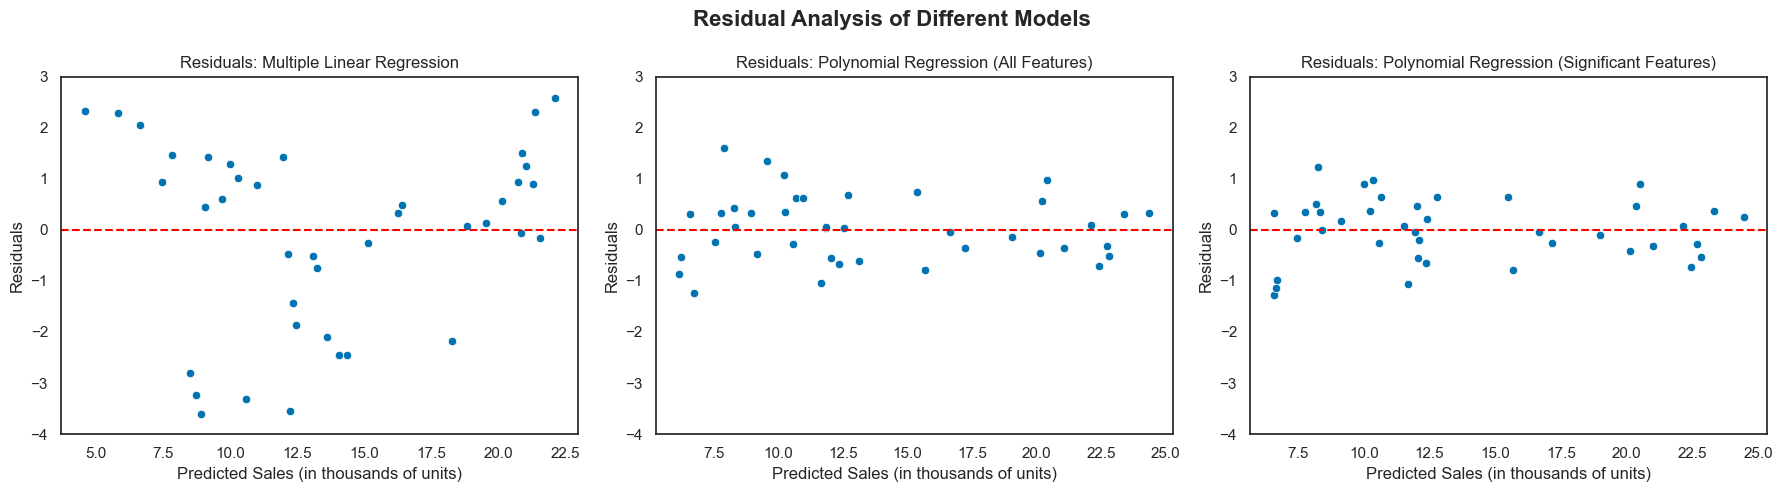

In [44]:
# Resuidual Analysis
residuals_mlr = y_test - y_pred_mlr
residuals_poly_all = y_test - y_pred_poly_all
residuals_poly_sig = y_test - y_pred_poly_sig

plt.figure(figsize=(18, 5))
plt.suptitle('Residual Analysis of Different Models', fontsize=16, fontweight='bold')

plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_mlr, y=residuals_mlr)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals: Multiple Linear Regression')
plt.xlabel('Predicted Sales (in thousands of units)')
plt.ylabel('Residuals')
plt.ylim(-4, 3)

plt.subplot(1, 3, 2)
sns.scatterplot(x=y_pred_poly_all, y=residuals_poly_all)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals: Polynomial Regression (All Features)')
plt.xlabel('Predicted Sales (in thousands of units)')
plt.ylabel('Residuals')
plt.ylim(-4, 3)

plt.subplot(1, 3, 3)
sns.scatterplot(x=y_pred_poly_sig, y=residuals_poly_sig)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals: Polynomial Regression (Significant Features)')
plt.xlabel('Predicted Sales (in thousands of units)')
plt.ylabel('Residuals')
plt.ylim(-4, 3)

plt.tight_layout()
plt.show()

#### 📌 Key Findings From Residual Analysis
- The residual plot for the Polynomial Regression model with degree 2 and using only `TV` and `Radio` as predictory, which performed better than the other two candidates, also shows a random scatter around zero, indicating that the model has effectively captured the non-linear relationship in the data.

### 8.3. Business Impact Analysis